# Tutorial 7 - Pandas, Numpy & Team Collaboration
### FINM3422 - Data Cleaning, Alignment, Multi‑Dataset Operations
---
This tutorial helps you build **real confidence** with Python, pandas, and numpy.
It is **not related to any assessment** - it builds generic modelling skills used in finance and data analysis.

You will:
- Clean small finance‑flavoured datasets
- Align dates & practice time‑series operations
- Merge DataFrames correctly
- Understand vectorisation vs loops
- Produce diagnostic charts
- Practice GitHub collaboration (branches + PRs) as a **team**

---

## 1. Environment Info

In [1]:
import sys, pandas as pd, numpy as np
print('Python:', sys.version)
print('pandas:', pd.__version__)
print('numpy:', np.__version__)

Python: 3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]
pandas: 2.2.3
numpy: 2.2.2


## 2. Imports & Settings

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme()

## 3. Generate Synthetic Finance‑Flavoured Datasets (No CSVs Needed)
We will create three small datasets directly in this notebook.
Each series mimics simple monthly price or return behaviour.

### ✅ Dataset A — Monthly prices for Asset A
### ✅ Dataset B — Monthly prices for Asset B
### ✅ Dataset C — Monthly returns for Asset C

Later, you will clean, align, merge, and analyse them.

In [3]:
# Generate synthetic data
dates = pd.date_range(start='2021-01-01', periods=24, freq='M')

np.random.seed(0)
assetA = 100 * (1 + 0.01*np.random.randn(24)).cumprod()
assetB = 80 * (1 + 0.015*np.random.randn(24)).cumprod()
assetC_returns = np.random.normal(loc=0.01, scale=0.03, size=24)  # already returns

dfA = pd.DataFrame({'PriceA': assetA}, index=dates)
dfB = pd.DataFrame({'PriceB': assetB}, index=dates)
dfC = pd.DataFrame({'RetC': assetC_returns}, index=dates)

dfA.head()

C:\Users\nicho\AppData\Local\Temp\ipykernel_57160\2669516881.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2021-01-01', periods=24, freq='M')


,PriceA
2021-01-31,101.7641
2021-02-28,102.1713
2021-03-31,103.1713
2021-04-30,105.4832
2021-05-31,107.4532


## 4. Inspection Tasks — *Team Split*
Assign ONE task per teammate. Add conclusions in markdown.

### ✅ Tasks:
- Inspect `.info()` on one dataset
- Inspect `.describe()`
- Check for missing values using `.isna().sum()`
- Check index type
- Infer frequency using `pd.infer_freq()`
- Check for duplicated dates using `.duplicated()`

In [15]:
# Example cell — students create their own below
dfA.info()

# .info()
print('=== dfA info ==='); dfA.info()
print('\n=== dfB info ==='); dfB.info()
print('\n=== dfC info ==='); dfC.info()

# .describe()
print(dfA.describe())
print(dfB.describe())
print(dfC.describe())

# Missing values
print('dfA:', dfA.isna().sum().to_dict())
print('dfB:', dfB.isna().sum().to_dict())
print('dfC:', dfC.isna().sum().to_dict())

# Index type
print(type(dfA.index), type(dfB.index), type(dfC.index))

# Infer frequency
print(pd.infer_freq(dfA.index))
print(pd.infer_freq(dfB.index))
print(pd.infer_freq(dfC.index))

# Duplicated dates
print(dfA.index.duplicated().sum())
print(dfB.index.duplicated().sum())
print(dfC.index.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24 entries, 2021-01-31 to 2022-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PriceA  24 non-null     float64
dtypes: float64(1)
memory usage: 384.0 bytes
=== dfA info ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24 entries, 2021-01-31 to 2022-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PriceA  24 non-null     float64
dtypes: float64(1)
memory usage: 384.0 bytes

=== dfB info ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24 entries, 2021-01-31 to 2022-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PriceB  24 non-null     float64
dtypes: float64(1)
memory usage: 384.0 bytes

=== dfC info ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24 entries, 2021-01-31 to 2022-12

## 5. Cleaning Tasks — *Team Split*
### Why we clean data
Real datasets contain issues: inconsistent dates, missing observations, incorrect datatypes.
Finance models fail if the underlying data is misaligned or dirty.

### ✅ Tasks (each member gets one):
- Convert index to true month‑end using `.to_period('M').to_timestamp('M')`
- Sort index and verify ascending order
- Forward fill missing prices (if any)
- Convert prices → returns using `.pct_change().dropna()`
- Convert string columns → numeric (if needed)
- Rename columns to standardised names (e.g., `PriceA`, `PriceB`, `RetC`)
- Add markdown describing what issue you fixed and why

In [16]:
# Example transformation (students extend)
dfA.index = dfA.index.to_period('M').to_timestamp('M')
dfA = dfA.sort_index()
dfA.head()

# Task 1: Convert to true month-end timestamps
dfA.index = dfA.index.to_period('M').to_timestamp('M')
dfB.index = dfB.index.to_period('M').to_timestamp('M')
dfC.index = dfC.index.to_period('M').to_timestamp('M')

# Task 2: Sort index and verify
dfA = dfA.sort_index()
dfB = dfB.sort_index()
dfC = dfC.sort_index()
print(dfA.index.is_monotonic_increasing)

# Task 3: Forward fill missing values (demo with injected NaN)
dfA_demo = dfA.copy()
dfA_demo.iloc[3] = np.nan
print(dfA_demo.iloc[2:6])
dfA_demo = dfA_demo.ffill()
print(dfA_demo.iloc[2:6])

# Task 4: Prices → returns
returnsA = dfA['PriceA'].pct_change().dropna().rename('RetA')
returnsB = dfB['PriceB'].pct_change().dropna().rename('RetB')
print(returnsA.head())

# Task 5: Rename columns (pattern for messy CSVs)
# dfA = dfA.rename(columns={'price_a': 'PriceA'})
print(dfA.columns.tolist(), dfB.columns.tolist(), dfC.columns.tolist())

True
             PriceA
2021-03-31 103.1713
2021-04-30      NaN
2021-05-31 107.4532
2021-06-30 106.4031
             PriceA
2021-03-31 103.1713
2021-04-30 103.1713
2021-05-31 107.4532
2021-06-30 106.4031
2021-02-28    0.0040
2021-03-31    0.0098
2021-04-30    0.0224
2021-05-31    0.0187
2021-06-30   -0.0098
Freq: ME, Name: RetA, dtype: float64
['PriceA'] ['PriceB'] ['RetC']


## 6. Time-Series Transformations 
### ✅ Compute simple monthly returns
### ✅ Wealth index
### ✅ Rolling averages/volatility
### ✅ Correlations between assets

These operations are used everywhere in finance, investment operations, and risk analysis.

In [18]:
# Returns for A and B
returnsA = dfA.pct_change().dropna()
returnsB = dfB.pct_change().dropna()

# Wealth index
wealthA = (1 + returnsA['PriceA']).cumprod()
wealthA.head()

# Wealth index
wealthA = (1 + returnsA).cumprod()
wealthB = (1 + returnsB).cumprod()
print(wealthA.head())

# Rolling 3-month mean and annualised volatility
rolling_mean_A = returnsA.rolling(window=3).mean()
rolling_vol_A  = returnsA.rolling(window=3).std() * np.sqrt(12)
print(rolling_mean_A.dropna().head())
print(rolling_vol_A.dropna().head())

# Correlation matrix
returns_combined = pd.concat([returnsA, returnsB, dfC['RetC']], axis=1, join='inner')
print(returns_combined.corr())

            PriceA
2021-02-28  1.0040
2021-03-31  1.0138
2021-04-30  1.0365
2021-05-31  1.0559
2021-06-30  1.0456
            PriceA
2021-04-30  0.0121
2021-05-31  0.0170
2021-06-30  0.0104
2021-07-31  0.0061
2021-08-31 -0.0006
            PriceA
2021-04-30  0.0326
2021-05-31  0.0225
2021-06-30  0.0610
2021-07-31  0.0503
2021-08-31  0.0335
        PriceA  PriceB    RetC
PriceA  1.0000 -0.0902  0.1960
PriceB -0.0902  1.0000 -0.0239
RetC    0.1960 -0.0239  1.0000


## 7. Merging / Joining Multiple DataFrames
Merging/joining datasets is crucial when combining sleeves, markets, or indicators.

### ✅ Try these joins:
- `inner` join
- `outer` join (shows missing dates if any)
- `left` join

Explain in markdown what difference you observed.

In [19]:
combined = dfA.join(dfB, how='inner')
combined.head()

# Inner join — only dates present in ALL DataFrames
combined_inner = dfA.join(dfB, how='inner').join(dfC, how='inner')
print('Inner:', combined_inner.shape)
print(combined_inner.head())

# Outer join — all dates; NaN where data is absent
combined_outer = dfA.join(dfB, how='outer').join(dfC, how='outer')
print('Outer:', combined_outer.shape)
print(combined_outer.isna().sum())

# Left join — anchored to dfA
combined_left = dfA.join(dfB, how='left').join(dfC, how='left')
print('Left:', combined_left.shape)
print(combined_left.head())

Inner: (24, 3)
             PriceA  PriceB    RetC
2021-01-31 101.7641 82.7237 -0.0384
2021-02-28 102.1713 80.9190  0.0036
2021-03-31 103.1713 80.9746 -0.0169
2021-04-30 105.4832 80.7472  0.0216
2021-05-31 107.4532 82.6037 -0.0053
Outer: (24, 3)
PriceA    0
PriceB    0
RetC      0
dtype: int64
Left: (24, 3)
             PriceA  PriceB    RetC
2021-01-31 101.7641 82.7237 -0.0384
2021-02-28 102.1713 80.9190  0.0036
2021-03-31 103.1713 80.9746 -0.0169
2021-04-30 105.4832 80.7472  0.0216
2021-05-31 107.4532 82.6037 -0.0053


## 8. Vectorisation vs Loops
Vectorised operations in pandas/numpy are *much faster* than Python loops.
This matters in finance where datasets can be millions of rows.

### ✅ Compare performance, clarity, correctness.

In [11]:
# Loop version (slow)
%timeit
out = []
for r in returnsA['PriceA']:
    out.append(r * 12)  # e.g., annualising monthly return (not exact)
loop_res = pd.Series(out, index=returnsA.index)

In [13]:
# Vectorised version (fast)
%timeit
vec_res = returnsA['PriceA'] * 12

## 9. Diagnostic Charts
Producing visual checks helps reveal missing data, misalignment, noise, or unusual movements.
Each team member creates **one chart**.

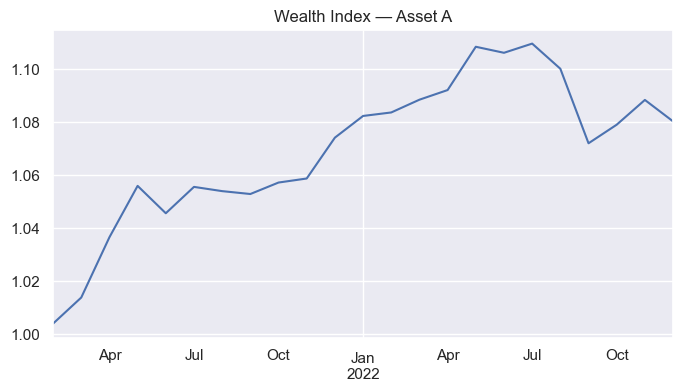

In [14]:
wealthA.plot(title='Wealth Index — Asset A', figsize=(8,4))
plt.show()

## 10. Team GitHub Workflow — Feature Branches & PRs

Each student:
1. Create a branch: `feature/t7_name_task`
2. Complete their assigned notebook task
3. Stage → Commit → Push (GUI only)
4. Open a Pull Request in the tutorial-team repo
5. Request review

Team lead:
- Reviews PRs
- Merges when safe
- Runs ‘Run All’ to check final notebook
- Pushes clean version


## 11. Final Checks Before Leaving

✅ Notebook runs top-to-bottom (Run All)
✅ No merge conflicts
✅ Data is clean
✅ Charts work
✅ All team PRs merged into `main`

---
**End of Tutorial 7 — Great work!**